# Block Encoding of FEM Operators: Circuits, Baselines, and Gate Counts

### Companion notebook to *Structured Block Encoding of the Finite Element Elasticity Operator*

---

This notebook covers the parts of the paper that live **below** the algebra: the
general-purpose baselines the method is measured against, the Qiskit circuits,
and what those circuits actually cost once compiled.

The algebra itself — how each operator decomposes, how boundary conditions
enter, why $\alpha$ behaves as it does — is worked out example by example in
three companion notebooks that need nothing but NumPy:

| Notebook | Content |
|---|---|
| `AppendixA_1D_Poisson.ipynb` | shifts, reflections, the three boundary treatments, the block encoding built by hand |
| `AppendixB_2D_Poisson.ipynb` | Kronecker merging, boundary treatment **by direction**, term counts as a product |
| `AppendixC_2D_Elasticity.ipynb` | the DOF qubit, the $\{I,Z,X\}$ components, the fourth component $iY$, the cantilever |

Start there if you want to understand the construction. Come here for
circuits and numbers.

**What this notebook establishes**

- General-purpose encoders cost $\alpha = 2^m$ (FABLE) or $\mathcal{O}(4^s)$ terms (Pauli); shift decomposition holds $L$ and $\alpha$ constant in $N$
- Qiskit circuits for Poisson and elasticity, verified against the classical operator to machine precision
- $A|x\rangle$ recovered by statevector simulation, with the post-selection success probability
- **Compiled two-qubit gate counts**, and the grid size at which structure starts paying
- An honest account of where this package's circuits differ from the paper's design

**Prerequisites:** `numpy`, `matplotlib`, `qiskit`, `qiskit-aer`, and this package.

```bash
pip install -e .
pip install numpy matplotlib qiskit qiskit-aer
```

> **Terminology.** Earlier drafts of this notebook called the method "pattern
> compression" and the $\{I,Z,X\}$ split "DOF channels". The paper uses the
> standard terms **shift decomposition** and **Pauli components**; this notebook
> follows the paper.
>
> **Boundary conditions.** The package imposes them with reflections adjoined
> to the unitary set, matching the paper. There is no flag qubit. Every
> encoder takes a `bc=` argument: `'periodic'`, `'essential'`, `'free'`, a
> pair such as `('clamped', 'free')` for one-sided conditions, or a dict such
> as `{'x': ('clamped','free'), 'y': 'free'}` for a cantilever.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from pyblockencode.operators import (
    poisson_1d_fdm, poisson_1d_fem,
    poisson_2d_fdm, poisson_2d_fem,
    poisson_3d_fdm, poisson_3d_fem,
    elasticity_q4,
)
from pyblockencode.poisson_pattern import PoissonPatternEncoding
from pyblockencode.elasticity_pattern import ElasticityPatternEncoding
from pyblockencode.qiskit_encoding import (
    PauliBlockEncoding, PoissonCircuit, ElasticityCircuit, apply_Ax,
)

import qiskit
print(f"qiskit {qiskit.__version__} — imports OK")

qiskit 2.5.2 — imports OK


## 1  Why structure matters

Quantum linear-algebra algorithms (HHL, QSVT, qubitization) do not act on a
matrix directly. They need a unitary $\mathcal{U}$ on $a + s$ qubits with

$$\mathbf{A} = \alpha\,\bigl(\langle 0|^{\otimes a}\otimes I\bigr)\,
   \mathcal{U}\,\bigl(|0\rangle^{\otimes a}\otimes I\bigr),$$

so $\mathbf{A}/\alpha$ occupies the top-left block. The subnormalization
$\alpha \geq \|\mathbf{A}\|$ enters downstream runtime **linearly**, so it
matters as much as gate count.

A general-purpose encoder works from raw matrix entries and pays for it.
Kuklinski et al. make the negative result precise: efficient block encodings
*require* structure. The operators of computational mechanics have it — they
are banded, built from a few repeated entries, and separable into Kronecker
factors.

**Shift decomposition** exploits exactly that: each 1D factor becomes a short
sum of cyclic shifts $S_c$, $S_c^\dagger$, giving $L = \mathcal{O}(1)$ terms and
$\alpha = \mathcal{O}(1)$, both independent of $N$.

## 2  Baselines: what "general purpose" costs

Two reference points. FABLE encodes any matrix from its entries at
$\alpha = 2^m$ — the subnormalization alone grows with the grid. Pauli-basis
expansion keeps $\alpha$ reasonable but the **term count** grows.

In [2]:
print(f"{'m':>3}{'N=2^m':>7}{'FABLE alpha = N':>18}{'shift-decomp alpha':>20}{'ratio':>9}")
print("-" * 60)
for m in range(1, 9):
    N = 2 ** m
    a_shift = PoissonPatternEncoding(m=m, dim=1, disc='fdm').alpha
    print(f"{m:>3}{N:>7}{float(N):>18.1f}{a_shift:>20.3f}{N/a_shift:>8.1f}x")
print("\nShift decomposition holds alpha = 4.000 at every grid size.")

# Pauli term count for the same operator
print(f"\n{'m':>3}{'N':>6}{'Pauli terms':>14}{'shift terms':>14}")
print("-" * 40)
from qiskit.quantum_info import SparsePauliOp
for m in range(1, 6):
    K = poisson_1d_fdm(m=m)
    npauli = len(SparsePauliOp.from_operator(K).coeffs)
    print(f"{m:>3}{2**m:>6}{npauli:>14}{PoissonPatternEncoding(m=m,dim=1,disc='fdm').num_terms:>14}")

  m  N=2^m   FABLE alpha = N  shift-decomp alpha    ratio
------------------------------------------------------------
  1      2               2.0               4.000     0.5x
  2      4               4.0               4.000     1.0x
  3      8               8.0               4.000     2.0x
  4     16              16.0               4.000     4.0x
  5     32              32.0               4.000     8.0x
  6     64              64.0               4.000    16.0x
  7    128             128.0               4.000    32.0x
  8    256             256.0               4.000    64.0x

Shift decomposition holds alpha = 4.000 at every grid size.

  m     N   Pauli terms   shift terms
----------------------------------------
  1     2             2             5
  2     4             4             5
  3     8             8             5
  4    16            16             5
  5    32            32             5


## 3  The 1D building blocks

Everything is assembled from three 1D factors. Appendix A works these out in
full, including the boundary treatments; here we only need their shift
expansions.

| Factor | Matrix | Shift expansion | $\alpha$ |
|---|---|---|---|
| Stiffness $\mathbf{K}_1$ | $\mathrm{tridiag}(-1,2,-1)$ | $2I - S_c - S_c^\dagger$ | 4 |
| Mass $\mathbf{M}_1$ | $\tfrac16\mathrm{tridiag}(1,4,1)$ | $\tfrac46 I + \tfrac16 S_c + \tfrac16 S_c^\dagger$ | 1 |
| Gradient $\mathbf{G}_1$ | $\tfrac12\mathrm{tridiag}(-1,0,1)$ | $\tfrac12 S_c^\dagger - \tfrac12 S_c$ | 1 |

The shifts are cyclic, so these expansions give the *periodic* operator. A
cyclic shift wraps in exactly one row — $S_c$ in row 0, $S_c^\dagger$ in row
$N-1$ — so deleting the wrap is a projector applied to that row, and
$\tfrac12(R_j + I) = I - |j\rangle\langle j|$ turns the projector into a
reflection:

$$S_c \;\longmapsto\; \tfrac12(R_0 + I)\,S_c,
  \qquad S_c^\dagger \;\longmapsto\; \tfrac12(R_{N-1} + I)\,S_c^\dagger .$$

Each shift splits into two terms of half the coefficient, so the term count
grows and $\alpha$ does not. Traction-free surfaces add a diagonal correction
that is again a combination of reflections. The unitary set is therefore

$$\{\,I,\; S_c,\; R_0 S_c,\; S_c^\dagger,\; R_{N-1} S_c^\dagger,\;
     R_0,\; R_{N-1}\,\},$$

of which the periodic case uses three, the clamped case five, a one-sided case
six and the traction-free case all seven. No flag qubit, no extra ancilla.

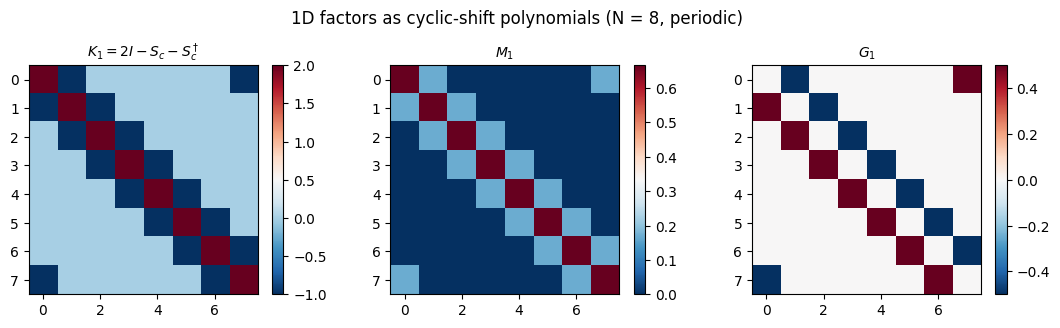

K1: alpha = 4.0,  corner entry (wrap) = -1.0000
M1: alpha = 1.0,  corner entry (wrap) = +0.1667
G1: alpha = 1.0,  corner entry (wrap) = +0.5000

  factor                  periodic                   clamped                      free
       K    3 terms, alpha = 4.000    5 terms, alpha = 4.000    7 terms, alpha = 4.000
       M    3 terms, alpha = 1.000    5 terms, alpha = 1.000    7 terms, alpha = 1.000
       G    2 terms, alpha = 1.000    4 terms, alpha = 1.000    6 terms, alpha = 1.500

alpha is untouched by the boundary treatment; only the term count moves.


In [3]:
def cyclic_shift(N):
    S = np.eye(N, k=1); S[-1, 0] = 1.0
    return S

m, N = 3, 8
I, Sc = np.eye(N), cyclic_shift(N); Scd = Sc.T
K1, M1, G1 = 2*I - Sc - Scd, (4*I + Sc + Scd)/6, (Scd - Sc)/2

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))
for ax, A, t in zip(axes, [K1, M1, G1],
                    [r'$K_1 = 2I - S_c - S_c^\dagger$',
                     r'$M_1$', r'$G_1$']):
    im = ax.imshow(A, cmap='RdBu_r'); ax.set_title(t, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle(f'1D factors as cyclic-shift polynomials (N = {N}, periodic)')
plt.tight_layout(); plt.show()

for lbl, A, a in [('K1', K1, 4.0), ('M1', M1, 1.0), ('G1', G1, 1.0)]:
    print(f"{lbl}: alpha = {a},  corner entry (wrap) = {A[0, -1]:+.4f}")

# the same factors under each boundary treatment, from the package
from pyblockencode import bc as bcmod
print()
print(f"{'factor':>8}" + "".join(f"{t:>26}" for t in
      ('periodic', 'clamped', 'free')))
for kind in ('K', 'M', 'G'):
    row = f"{kind:>8}"
    for t in ('periodic', 'essential', 'free'):
        d = bcmod.factor(kind, t)
        row += f"{f'{len(d)} terms, alpha = {bcmod.alpha(d):.3f}':>26}"
    print(row)
print("\nalpha is untouched by the boundary treatment; only the term count moves.")

## 4  Poisson in one, two and three dimensions

Separability means the 2D and 3D operators merge onto products of the same 1D
basis. Appendix B does the 2D case by hand; 3D is included here because the
companion notebooks stop at two.

In [4]:
print(f"{'operator':<12}{'bc':<11}{'L':>5}{'alpha':>10}{'qubits':>8}"
      f"{'worst err':>12}")
print("-" * 58)
for dim in (1, 2, 3):
    for disc in ('fdm', 'fem'):
        for b in ('periodic', 'essential', 'free'):
            e = PoissonPatternEncoding(m=2, dim=dim, disc=disc, bc=b)
            r = e.verify()
            worst = max(v for k, v in r.items()
                        if k.endswith('_err') or k.startswith('vs_'))
            print(f"{f'{dim}D {disc.upper()}':<12}{b:<11}{e.num_terms:>5}"
                  f"{e.alpha:>10.4f}{e.num_qubits:>8}{worst:>12.2e}")
            assert worst < 1e-11
print("\nalpha depends on the operator, never on the boundary treatment.")

operator    bc             L     alpha  qubits   worst err
----------------------------------------------------------
1D FDM      periodic       3    4.0000       4    1.68e-15
1D FDM      essential      5    4.0000       5    1.54e-15
1D FDM      free           7    4.0000       5    1.93e-15
1D FEM      periodic       3    4.0000       4    1.68e-15
1D FEM      essential      5    4.0000       5    1.54e-15
1D FEM      free           7    4.0000       5    1.93e-15
2D FDM      periodic       5    8.0000       7    3.05e-15
2D FDM      essential      9    8.0000       8    7.30e-15
2D FDM      free          13    8.0000       8    7.31e-15
2D FEM      periodic       9    5.3333       8    7.36e-15
2D FEM      essential     25    5.3333       9    1.65e-14


2D FEM      free          49    5.3333      10    2.35e-14
3D FDM      periodic       7   12.0000       9    8.60e-15
3D FDM      essential     13   12.0000      10    1.65e-14


3D FDM      free          19   12.0000      11    2.28e-14
3D FEM      periodic      21    5.3333      11    2.13e-14
3D FEM      essential    113    5.3333      13    1.36e-18
3D FEM      free         235    5.3333      14    1.43e-16

alpha depends on the operator, never on the boundary treatment.


## 5  Elasticity: the 17-term LCU

The $2\times2$ displacement block collapses onto a single DOF qubit,

$$\mathbf{K} = \frac{\mathbf{K}_{xx}+\mathbf{K}_{yy}}{2}\otimes I
             + \frac{\mathbf{K}_{xx}-\mathbf{K}_{yy}}{2}\otimes Z
             + \mathbf{K}_{xy}\otimes X,$$

three **Pauli components** on the same nine shift offsets as 2D Poisson, giving
17 terms rather than 9 for the periodic operator, and 49 once essential
conditions split each shift.

Opening a boundary destroys the antisymmetry of $\mathbf{G}_1$, so
$\mathbf{K}_{xy}$ is no longer symmetric and a **fourth** component
$iY = \bigl(\begin{smallmatrix}0 & 1\\ -1 & 0\end{smallmatrix}\bigr)$
appears. Appendix C derives all of this.

In [5]:
print(f"{'boundary treatment':<24}{'L':>5}{'alpha':>10}{'components':>18}"
      f"{'anc':>5}{'qubits':>8}")
print("-" * 70)
for lbl, spec in [('periodic', 'periodic'), ('all edges clamped', 'essential'),
                  ('clamped left+right', [('clamped','clamped'), ('free','free')]),
                  ('clamped left only', [('clamped','free'), ('free','free')]),
                  ('traction-free', 'free')]:
    e = ElasticityPatternEncoding(m=2, E=1.0, nu=0.3, bc=spec)
    r = e.verify()
    print(f"{lbl:<24}{e.num_terms:>5}{e.alpha:>10.4f}"
          f"{''.join(e.components):>18}{e.num_ancilla:>5}{e.num_qubits:>8}")
    assert r['decomposition_rel_err'] < 1e-12
    assert r['vs_q4_assembly'] < 1e-12

e = ElasticityPatternEncoding(m=2, E=1.0, nu=0.3, bc='periodic')
print(f"\nthe 17 periodic terms:")
comp_of = {'I': 'I  (isotropic)', 'Z': 'Z  (anisotropy)', 'X': 'X  (shear)'}
for k, c in sorted(e.lcu_terms().items()):
    print(f"  {str(k):<22} {c:+.6f}   {comp_of.get(k[-1], k[-1])}")

print("\nclosed form alpha(nu) = E(33+nu) / (6(1-nu^2)):")
for nu in (0.0, 0.3, 0.45):
    a = ElasticityPatternEncoding(m=2, E=1.0, nu=nu, bc='periodic').alpha
    print(f"  nu={nu:<5} alpha={a:.6f}   closed form={(33+nu)/(6*(1-nu**2)):.6f}")
    assert abs(a - (33+nu)/(6*(1-nu**2))) < 1e-10

boundary treatment          L     alpha        components  anc  qubits
----------------------------------------------------------------------


periodic                   17    6.0989               IZX    5      10


all edges clamped          49    6.0989               IZX    6      11


clamped left+right         75    6.1264             IZXiY    7      12


clamped left only          98    6.3324             IZXiY    7      12


traction-free             109    6.3324             IZXiY    7      12

the 17 periodic terms:
  ('I', 'I', 'I')        +1.978022   I  (isotropic)
  ('I', 'Sc', 'I')       -0.247253   I  (isotropic)
  ('I', 'Sc', 'Z')       +0.357143   Z  (anisotropy)
  ('I', 'Scd', 'I')      -0.247253   I  (isotropic)
  ('I', 'Scd', 'Z')      +0.357143   Z  (anisotropy)
  ('Sc', 'I', 'I')       -0.247253   I  (isotropic)
  ('Sc', 'I', 'Z')       -0.357143   Z  (anisotropy)
  ('Sc', 'Sc', 'I')      -0.247253   I  (isotropic)
  ('Sc', 'Sc', 'X')      -0.178571   X  (shear)
  ('Sc', 'Scd', 'I')     -0.247253   I  (isotropic)
  ('Sc', 'Scd', 'X')     +0.178571   X  (shear)
  ('Scd', 'I', 'I')      -0.247253   I  (isotropic)
  ('Scd', 'I', 'Z')      -0.357143   Z  (anisotropy)
  ('Scd', 'Sc', 'I')     -0.247253   I  (isotropic)
  ('Scd', 'Sc', 'X')     +0.178571   X  (shear)
  ('Scd', 'Scd', 'I')    -0.247253   I  (isotropic)
  ('Scd', 'Scd', 'X')    -0.178571   X  (shear)

closed form alpha(nu) = E(33+nu)

## 6  How tight is $\alpha$? — and a cautionary tale

An earlier version of this notebook measured $\alpha / \|\mathbf{K}\|_2$ at
$m = 2$ (a $4\times4$ node grid) and reported $\approx 1.6$. That number
reached the paper and was **wrong** — not because the ratio was mis-measured,
but because $\|\mathbf{K}\|_2$ has not converged on so small a grid.

Sweeping $N$ shows the ratio settling near $1.39$. The lesson is worth keeping
visible: a tightness ratio quoted at one small grid size is not a property of
the encoding.

  m    N    alpha   ||K||_2  ||K||_inf  a/||K||_2  a/||K||_inf
--------------------------------------------------------------
  1    2   6.0989    3.1181     3.1181     1.9559       1.9559
  2    4   6.0989    3.7972     5.1099     1.6062       1.1935
  3    8   6.0989    4.1955     5.1099     1.4537       1.1935
  4   16   6.0989    4.3381     5.1099     1.4059       1.1935


  5   32   6.0989    4.3802     5.1099     1.3924       1.1935


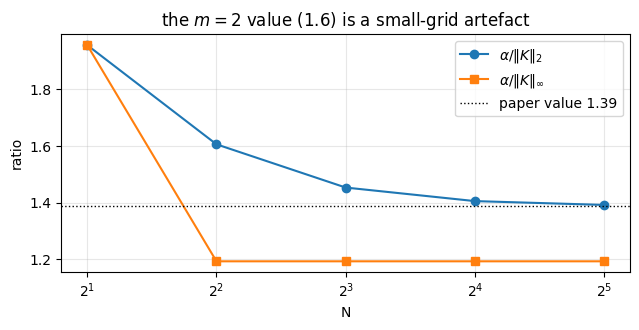


at m=2 : alpha/||K||_2 = 1.606   <- the number that reached the paper
at m=5 : alpha/||K||_2 = 1.392   <- converged
alpha/||K||_inf is already at its limit at every N: it does not depend on the grid.


In [6]:
ms = list(range(1, 6))
print(f"{'m':>3}{'N':>5}{'alpha':>9}{'||K||_2':>10}{'||K||_inf':>11}"
      f"{'a/||K||_2':>11}{'a/||K||_inf':>13}")
print("-" * 62)
r2, rinf = [], []
for m_ in ms:
    enc = ElasticityPatternEncoding(m=m_, E=1.0, nu=0.3)
    K = enc.target()
    a = enc.alpha
    n2, ninf = np.linalg.norm(K, 2), np.abs(K).sum(1).max()
    r2.append(a/n2); rinf.append(a/ninf)
    print(f"{m_:>3}{2**m_:>5}{a:>9.4f}{n2:>10.4f}{ninf:>11.4f}"
          f"{a/n2:>11.4f}{a/ninf:>13.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot([2**m_ for m_ in ms], r2, 'o-', label=r'$\alpha/\|K\|_2$')
ax.plot([2**m_ for m_ in ms], rinf, 's-', label=r'$\alpha/\|K\|_\infty$')
ax.axhline(1.39, color='k', ls=':', lw=1, label='paper value 1.39')
ax.set_xscale('log', base=2); ax.set_xlabel('N'); ax.set_ylabel('ratio')
ax.set_title(r'the $m=2$ value (1.6) is a small-grid artefact')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

print(f"\nat m=2 : alpha/||K||_2 = {r2[1]:.3f}   <- the number that reached the paper")
print(f"at m=5 : alpha/||K||_2 = {r2[-1]:.3f}   <- converged")
print("alpha/||K||_inf is already at its limit at every N: it does not depend on the grid.")

## 7  $L$ and $\alpha$ are constant in $N$

The central claim, checked across grid sizes for every operator.

In [7]:
cases = [
    ('Poisson 1D FDM', lambda m: PoissonPatternEncoding(m=m, dim=1, disc='fdm')),
    ('Poisson 1D FEM', lambda m: PoissonPatternEncoding(m=m, dim=1, disc='fem')),
    ('Poisson 2D FDM', lambda m: PoissonPatternEncoding(m=m, dim=2, disc='fdm')),
    ('Poisson 2D FEM', lambda m: PoissonPatternEncoding(m=m, dim=2, disc='fem')),
    ('Poisson 3D FDM', lambda m: PoissonPatternEncoding(m=m, dim=3, disc='fdm')),
    ('Poisson 3D FEM', lambda m: PoissonPatternEncoding(m=m, dim=3, disc='fem')),
    ('Elasticity 2D',  lambda m: ElasticityPatternEncoding(m=m, nu=0.3)),
]
ms = list(range(1, 9))
print(f"{'operator':<18}" + "".join(f"{'m=%d'%m:>7}" for m in ms))
print("-" * (18 + 7*len(ms)))
print("L:")
for lbl, f in cases:
    Ls = [f(m).num_terms for m in ms]
    print(f"  {lbl:<16}" + "".join(f"{L:>7}" for L in Ls))
    assert len(set(Ls)) == 1
print("alpha:")
for lbl, f in cases:
    al = [f(m).alpha for m in ms]
    print(f"  {lbl:<16}" + "".join(f"{a:>7.3f}" for a in al))
    assert max(al) - min(al) < 1e-12
print("\nEvery row is constant. Doubling the resolution adds a qubit, not a term.")

operator              m=1    m=2    m=3    m=4    m=5    m=6    m=7    m=8
--------------------------------------------------------------------------
L:
  Poisson 1D FDM        5      5      5      5      5      5      5      5
  Poisson 1D FEM        5      5      5      5      5      5      5      5
  Poisson 2D FDM        9      9      9      9      9      9      9      9
  Poisson 2D FEM       25     25     25     25     25     25     25     25
  Poisson 3D FDM       13     13     13     13     13     13     13     13
  Poisson 3D FEM      113    113    113    113    113    113    113    113
  Elasticity 2D        49     49     49     49     49     49     49     49
alpha:
  Poisson 1D FDM    4.000  4.000  4.000  4.000  4.000  4.000  4.000  4.000
  Poisson 1D FEM    4.000  4.000  4.000  4.000  4.000  4.000  4.000  4.000
  Poisson 2D FDM    8.000  8.000  8.000  8.000  8.000  8.000  8.000  8.000
  Poisson 2D FEM    5.333  5.333  5.333  5.333  5.333  5.333  5.333  5.333
  Poisson 3D FD

## 8  Qubit scaling

$L$ and $\alpha$ are fixed; the qubit count grows linearly in $m$, as it must.

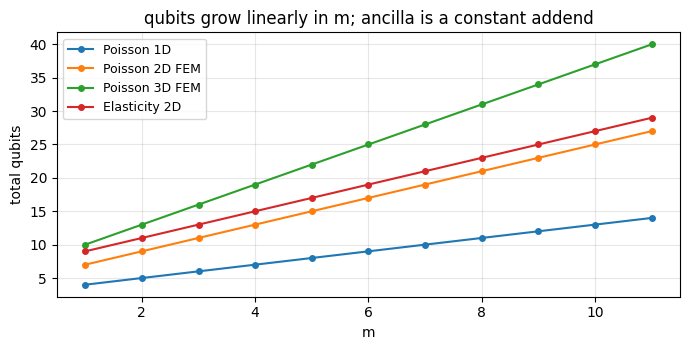

  Poisson 1D       qubits = 1m + 3
  Poisson 2D FEM   qubits = 2m + 5
  Poisson 3D FEM   qubits = 3m + 7
  Elasticity 2D    qubits = 2m + 7


In [8]:
ms_q = list(range(1, 12))
qc_cases = [
    ('Poisson 1D', lambda m: PoissonPatternEncoding(m=m, dim=1, disc='fdm')),
    ('Poisson 2D FEM', lambda m: PoissonPatternEncoding(m=m, dim=2, disc='fem')),
    ('Poisson 3D FEM', lambda m: PoissonPatternEncoding(m=m, dim=3, disc='fem')),
    ('Elasticity 2D', lambda m: ElasticityPatternEncoding(m=m, nu=0.3)),
]
fig, ax = plt.subplots(figsize=(7, 3.6))
for lbl, f in qc_cases:
    ax.plot(ms_q, [f(m).num_qubits for m in ms_q], 'o-', ms=4, label=lbl)
ax.set_xlabel('m'); ax.set_ylabel('total qubits'); ax.legend(fontsize=9)
ax.set_title('qubits grow linearly in m; ancilla is a constant addend')
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

for lbl, f in qc_cases:
    s = f(2).num_qubits - f(1).num_qubits
    print(f"  {lbl:<16} qubits = {s}m + {f(1).num_qubits - s}")

## 9  Resource summary

Figures for the essential-boundary elasticity encoding, matching Table 3 of the
paper. Everything here is read out of the package rather than hard-coded.

In [9]:
m_ = 3
e = ElasticityPatternEncoding(m=m_, E=1.0, nu=0.3, bc='essential')
ef = ElasticityPatternEncoding(m=m_, E=1.0, nu=0.3, bc='free')
print("Elasticity Q4 block encoding, essential boundary conditions (E = 1)")
print("-" * 66)
print(f"  {'System qubits':<28} 2m + 1  = {e.num_system}")
print(f"  {'PREP ancilla':<28} ceil(log2 {e.num_terms}) = {e.num_ancilla}")
print(f"  {'Flag ancilla':<28} none")
print(f"  {'Total qubits':<28} 2m + {e.num_qubits - 2*m_}  = {e.num_qubits}")
print(f"  {'LCU terms L':<28} "
      f"{ElasticityPatternEncoding(m=m_,nu=0.3,bc='periodic').num_terms} periodic / "
      f"{e.num_terms} essential / {ef.num_terms} traction-free")
for nu_ in (0.0, 0.30, 0.45):
    a = ElasticityPatternEncoding(m=m_, nu=nu_, bc='essential').alpha
    print(f"  {f'alpha (nu={nu_:.2f})':<28} {a:.4f}")
print(f"  {'alpha / ||K||_2':<28} ~ 1.39  (converged; see Section 6)")
print(f"  {'information eff. eta':<28} ~ 0.72")
print(f"  {'Pauli components':<28} {', '.join(e.components)}  "
      f"(+ iY when free: {', '.join(ef.components)})")
print(f"  {'Boundary conditions':<28} reflections adjoined to the unitary set")

assert e.num_qubits == 2 * m_ + 7 and e.num_terms == 49
assert 'iY' in ef.components and 'iY' not in e.components

Elasticity Q4 block encoding, essential boundary conditions (E = 1)
------------------------------------------------------------------
  System qubits                2m + 1  = 7
  PREP ancilla                 ceil(log2 49) = 6
  Flag ancilla                 none
  Total qubits                 2m + 7  = 13
  LCU terms L                  17 periodic / 49 essential / 109 traction-free
  alpha (nu=0.00)              5.5000
  alpha (nu=0.30)              6.0989
  alpha (nu=0.45)              6.9906
  alpha / ||K||_2              ~ 1.39  (converged; see Section 6)
  information eff. eta         ~ 0.72
  Pauli components             I, Z, X  (+ iY when free: I, Z, X, iY)
  Boundary conditions          reflections adjoined to the unitary set


## 10  Comparison with prior work

Condensed from the paper's literature review. The dividing line is whether the
term count is constant in $N$.

| Work | Paradigm | Elasticity? | Const. terms? | Depth | Key gap |
|---|---|---|---|---|---|
| Rémond et al. | VQA / NISQ Pauli meas. | Yes (Q4 full) | No — $\mathcal{O}(n_xn_y)$ | N/A | not a block encoding |
| Danz et al. | arithmetic value oracle | No (1D scalar) | No — $\mathcal{O}(r^2)$/entry | $\mathcal{O}(r^2)$ | scalar, 1D |
| Qu-FEM | fault-tolerant LCU + shifts | No (scalar) | Yes (scalar) | $\mathcal{O}(n)$ | vector elasticity out of scope |
| Lu et al. | VQLS; Pauli and SVD LCU | No (scalar CFD) | No (Pauli); 2 (SVD) | $\mathcal{O}(4^s)$/term | SVD factors lack efficient circuits |
| Arora et al. | element QSD + permute | Yes (Q4 element) | No — $\mathcal{O}(N)$ depth | linear in $N$ | encodes element, not global |
| Kharazi et al. | shift LCU, FDM | No (scalar) | Yes (scalar) | $\mathcal{O}(n)$ | scalar Laplacian only |
| Cobble, Unitaria | compilers; compose encodings | N/A | N/A | inherits | need the basic encoding as input |
| **This work** | **shift-decomposition LCU** | **Yes, Q4 full** | **Yes — 17/49/109** | $\mathcal{O}(m)$ | — |

The last column of the paper's version carries the full discussion. Two points
worth restating: Cobble and Unitaria are *complementary*, consuming exactly the
kind of object this work produces; and the singular-value dilation used by Lu
et al. reaches $L = 2$ at optimal $\alpha$ for any matrix, but with dense
unstructured factors that have no efficient circuit — minimal term count is not
automatically a bargain.

---
## 11  Circuits

Everything above works with dense NumPy matrices. This section generates actual
Qiskit circuits and verifies them by simulation.

**Convention.** System register declared first (LSB), ancilla second (MSB), so
$\mathbf{A}/\alpha$ sits in the contiguous top-left corner:

```python
QuantumCircuit(qr_sys, qr_flag, qr_anc)     # system LSB, ancilla MSB
alpha * Operator(qc).data[:N0, :N0]  ==  A
```

### 11.1  Pauli LCU — the general-purpose baseline

In [10]:
K4 = poisson_1d_fdm(m=2)
pbe = PauliBlockEncoding(K4)
r = pbe.verify()
print(f"Pauli LCU:  terms = {pbe.num_terms},  alpha = {pbe.alpha:.4f}, "
      f"qubits = {pbe.circuit().num_qubits}")
print(f"  block encoding rel err = {r['block_encoding_rel_err']:.2e}")
print(f"  unitarity err          = {r['unitarity_err']:.2e}")
assert r['block_encoding_rel_err'] < 1e-12

Pauli LCU:  terms = 4,  alpha = 4.0000, qubits = 4
  block encoding rel err = 1.05e-15
  unitarity err          = 7.61e-15


### 11.2  Poisson circuits — shift decomposition

In [11]:
for lbl, kw in [('1D FDM periodic', dict(m=2, dim=1, disc='fdm', bc='periodic')),
                ('1D FDM clamped', dict(m=2, dim=1, disc='fdm', bc='essential')),
                ('1D FDM free', dict(m=2, dim=1, disc='fdm', bc='free')),
                ('1D FDM one-sided', dict(m=2, dim=1, disc='fdm',
                                          bc=('clamped', 'free'))),
                ('2D FDM mixed', dict(m=2, dim=2, disc='fdm',
                                      bc={'x': 'essential', 'y': 'free'}))]:
    t0 = time.time()
    pc = PoissonCircuit(**kw); r = pc.verify()
    print(f"Poisson {lbl:<17} L = {pc.num_terms:>2}, alpha = {pc.alpha:.4f}, "
          f"qubits = {pc.num_qubits}")
    print(f"   ||alpha*U[:N0,:N0] - K|| / ||K|| = {r['block_encoding_rel_err']:.2e}"
          f"   ({time.time()-t0:.0f}s)")
    assert r['block_encoding_rel_err'] < 1e-11

Poisson 1D FDM periodic   L =  3, alpha = 4.0000, qubits = 4
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 1.15e-15   (0s)


Poisson 1D FDM clamped    L =  5, alpha = 4.0000, qubits = 5
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 3.29e-14   (0s)


Poisson 1D FDM free       L =  7, alpha = 4.0000, qubits = 5
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 5.39e-14   (0s)


Poisson 1D FDM one-sided  L =  6, alpha = 4.0000, qubits = 5
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 4.31e-14   (0s)


Poisson 2D FDM mixed      L = 11, alpha = 8.0000, qubits = 8
   ||alpha*U[:N0,:N0] - K|| / ||K|| = 2.12e-13   (5s)


### 11.3  Elasticity circuit

The periodic case is checked by building the full unitary. The larger term
counts are checked end to end in Section 11.4 instead: the dense operator of a
109-term circuit is prohibitive, while a statevector simulation is not.

In [12]:
t0 = time.time()
ec = ElasticityCircuit(m=1, E=1.0, nu=0.3, bc='periodic')
print(f"Elasticity Q4, m=1, nu=0.3, periodic:  L = {ec.num_terms}, "
      f"alpha = {ec.alpha:.4f}, qubits = {ec.num_qubits}")
r = ec.verify()
print(f"  ||alpha*U[:N0,:N0] - K|| / ||K|| = {r['block_encoding_rel_err']:.2e}")
print(f"  ||U^dag U - I||                  = {r['unitarity_err']:.2e}")
print(f"  ({time.time()-t0:.0f}s)")
assert r['block_encoding_rel_err'] < 1e-10

Elasticity Q4, m=1, nu=0.3, periodic:  L = 17, alpha = 6.0989, qubits = 8


  ||alpha*U[:N0,:N0] - K|| / ||K|| = 1.86e-13
  ||U^dag U - I||                  = 5.85e-12
  (5s)


### 11.4  Recovering $A|x\rangle$ by simulation

Prepare $|x\rangle$ on the system register, run the circuit, post-select the
ancilla on $|0\rangle$, rescale by $\alpha$:

$$\mathcal{U}\,\bigl(|x\rangle_{\rm sys}\otimes|0\rangle_{\rm anc}\bigr)
 = \tfrac1\alpha\, A|x\rangle\,|0\rangle_{\rm anc} + |\text{garbage}\rangle .$$

The success probability $p = \|A|x\rangle\|^2/\alpha^2$ is what post-selection
costs, and it is bounded by $\|A\|^2/\alpha^2$ — which is exactly why the
tightness of $\alpha$ in Section 6 matters in practice.

operator                            max rel err              success prob
--------------------------------------------------------------------------
Poisson 1D, clamped                    3.71e-14          [0.0256, 0.1654]


Elasticity, clamped (L=49)             1.04e-12          [0.0406, 0.0690]


Elasticity, cantilever (L=98)          4.54e-12          [0.0043, 0.0124]


Elasticity, traction-free (L=109)      5.27e-12          [0.0005, 0.0101]


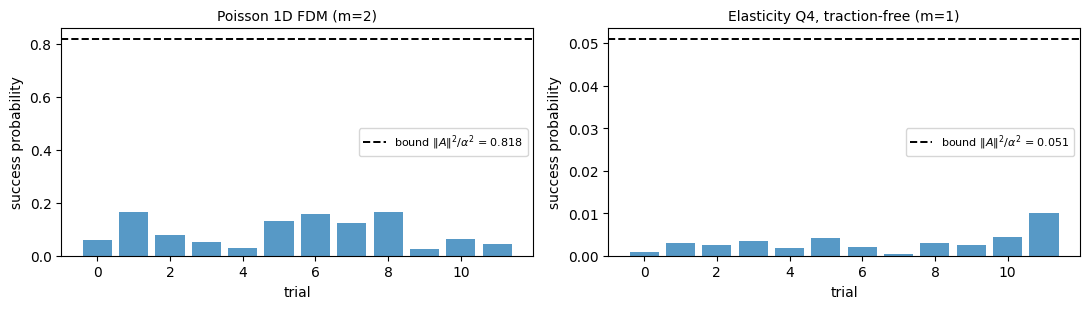

In [13]:
rng = np.random.default_rng(0)

def ax_trials(enc, n_dof, n=12):
    errs, ps = [], []
    for _ in range(n):
        x = rng.random(n_dof) + 1j*rng.random(n_dof); x /= np.linalg.norm(x)
        r = apply_Ax(enc, x)
        errs.append(r['rel_err']); ps.append(r['success_prob'])
    return np.array(errs), np.array(ps)

pc = PoissonCircuit(m=2, dim=1, disc='fdm', bc='essential')
e_p, p_p = ax_trials(pc, 4)
print(f"{'operator':<34}{'max rel err':>13}{'success prob':>26}")
print("-" * 74)
print(f"{'Poisson 1D, clamped':<34}{e_p.max():>13.2e}"
      f"{f'[{p_p.min():.4f}, {p_p.max():.4f}]':>26}")
assert e_p.max() < 1e-10

for lbl, spec in [('clamped', 'essential'),
                  ('cantilever', [('clamped', 'free'), ('free', 'free')]),
                  ('traction-free', 'free')]:
    ec = ElasticityCircuit(m=1, E=1.0, nu=0.3, bc=spec)
    e_e, p_e = ax_trials(ec, 2 * ec.enc.N**2)
    print(f"{f'Elasticity, {lbl} (L={ec.num_terms})':<34}{e_e.max():>13.2e}"
          f"{f'[{p_e.min():.4f}, {p_e.max():.4f}]':>26}")
    assert e_e.max() < 1e-10

bound_p = np.linalg.norm(pc.target(), 2)**2 / pc.alpha**2
bound_e = np.linalg.norm(ec.target(), 2)**2 / ec.alpha**2      # traction-free
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, ps, b, t in [(axes[0], p_p, bound_p, 'Poisson 1D FDM (m=2)'),
                     (axes[1], p_e, bound_e,
                      'Elasticity Q4, traction-free (m=1)')]:
    ax.bar(range(len(ps)), ps, alpha=.75)
    ax.axhline(b, color='k', ls='--', lw=1.4,
               label=r'bound $\|A\|^2/\alpha^2$ = %.3f' % b)
    ax.set_xlabel('trial'); ax.set_ylabel('success probability')
    ax.set_title(t, fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 11.5  Compiled gate counts: where structure starts paying

This is the comparison an earlier version of this notebook got wrong by
stopping at $N = 4$. At that size the general-purpose Pauli encoder genuinely
*is* cheaper — the structured circuit carries fixed overhead that a $4\times4$
matrix never amortizes. Reporting only that point makes the method look far
worse than the baseline it beats.

Correct boundary conditions are not free here: the clamped operator has five
terms rather than three, and each reflection is a multi-controlled $Z$, so the
crossover sits further out than it would for the periodic operator. That is
the honest number. The asymptotics are what matter — Pauli roughly quadruples
per added qubit while the shift decomposition less than doubles.

Sweeping the grid (this stops at $N = 128$ to keep the notebook quick; the
trend continues — measured separately, $N = 256$ gives a ratio of 3.9 and
$N = 512$ gives 7.6, at 251k CX against 1.90M):

     N    Pauli CX   shift-decomp CX    ratio
----------------------------------------------


     4          38               552     0.07


     8         282              2492     0.11


    16        1986              7640     0.26


    32       11592             20932     0.55


    64       47406             47232     1.00


   128      177260             88860     1.99


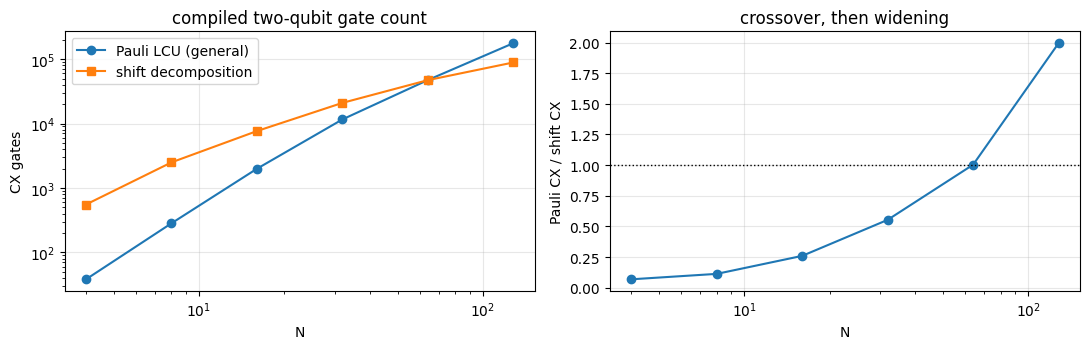


crossover at N = 64; at N = 128 the structured circuit is 2.0x cheaper
growth per added qubit at the top of the sweep: Pauli 3.74x, shift decomposition 1.88x


In [14]:
from qiskit import transpile

def cx_count(qc, reps=6):
    qt = transpile(qc.decompose(reps=reps), basis_gates=['u', 'cx'],
                   optimization_level=1)
    return qc.num_qubits, qt.depth(), qt.count_ops().get('cx', 0)

sweep = []
print(f"{'N':>6}{'Pauli CX':>12}{'shift-decomp CX':>18}{'ratio':>9}")
print("-" * 46)
for m_ in range(2, 8):
    _, _, cx_pauli = cx_count(PauliBlockEncoding(poisson_1d_fdm(m=m_)).circuit())
    _, _, cx_shift = cx_count(
        PoissonCircuit(m=m_, dim=1, disc='fdm', bc='essential').circuit())
    sweep.append((2**m_, cx_pauli, cx_shift))
    print(f"{2**m_:>6}{cx_pauli:>12}{cx_shift:>18}{cx_pauli/cx_shift:>9.2f}")

Ns = [s[0] for s in sweep]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.loglog(Ns, [s[1] for s in sweep], 'o-', label='Pauli LCU (general)')
a1.loglog(Ns, [s[2] for s in sweep], 's-', label='shift decomposition')
a1.set_xlabel('N'); a1.set_ylabel('CX gates'); a1.legend(); a1.grid(alpha=.3)
a1.set_title('compiled two-qubit gate count')
a2.semilogx(Ns, [s[1]/s[2] for s in sweep], 'o-')
a2.axhline(1.0, color='k', ls=':', lw=1)
a2.set_xlabel('N'); a2.set_ylabel('Pauli CX / shift CX')
a2.set_title('crossover, then widening'); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

cross = next((N for N, pa, sh in sweep if pa > sh), None)
gp = sweep[-1][1] / sweep[-2][1]
gs = sweep[-1][2] / sweep[-2][2]
print(f"\ncrossover at N = {cross}; at N = {sweep[-1][0]} the structured circuit is "
      f"{sweep[-1][1]/sweep[-1][2]:.1f}x cheaper")
print(f"growth per added qubit at the top of the sweep: "
      f"Pauli {gp:.2f}x, shift decomposition {gs:.2f}x")

### 11.6  What this circuit layer is — and is not

The gate counts above are honest measurements of *this package's* circuits, and
those circuits are **not** the SELECT described in Section 7.3 of the paper.

The paper's SELECT reads the ancilla index as **fields** — shift exponents,
reflection flags, a Pauli index — and applies a constant number of parameterized
operations: two adders, two reflections, one Pauli, independent of $L$. That is
what gives $\mathcal{O}(m)$ depth.

`qiskit_encoding.py` instead builds one fully-controlled block per LCU term:

```python
for i, key in enumerate(labels):
    ctrl_gate = sel_circ.to_gate().control(na_prep, ctrl_state=format(i, ...))
```

This is the textbook LCU harness. It is correct — everything above verifies to
machine precision — but its cost is $\mathcal{O}(L)$ controlled blocks, and the
measured depth reflects that, not the paper's design.

In [15]:
print(f"{'m':>3}{'N':>6}{'qubits':>8}{'depth':>10}{'CX':>10}{'CX ratio':>10}")
print("-" * 48)
prev = None
for m_ in range(1, 4):
    qc = ElasticityCircuit(m=m_, E=1.0, nu=0.3, bc='essential').circuit()
    q, d, cx = cx_count(qc)
    rs = f"{cx/prev:.2f}" if prev else "--"
    print(f"{m_:>3}{2**m_:>6}{q:>8}{d:>10}{cx:>10}{rs:>10}")
    prev = cx

print("\nCX grows by roughly 3x per added qubit per dimension.")
print("An O(m)-depth SELECT would grow linearly in m instead.")
print("Implementing the adder-based SELECT is the open engineering task;")
print("until then, do not quote these gate counts as evidence for the")
print("paper's polylogarithmic-depth claim.")

  m     N  qubits     depth        CX  CX ratio
------------------------------------------------


  1     2       9     40237     28898        --


  2     4      11    114163     80898      2.80


  3     8      13    468313    330338      4.08

CX grows by roughly 3x per added qubit per dimension.
An O(m)-depth SELECT would grow linearly in m instead.
Implementing the adder-based SELECT is the open engineering task;
until then, do not quote these gate counts as evidence for the
paper's polylogarithmic-depth claim.


---
## 12  Where the package and the paper still differ

The boundary treatment now matches the paper: reflections adjoined to the
unitary set, no flag qubit, essential and traction-free and mixed conditions,
and the fourth Pauli component appearing exactly when a boundary opens. All of
it is checked in `pyblockencode/smoke_test.py`.

One difference remains, and it is the one in Section 11.6.

**SELECT.** The paper's Section 7.3 decodes the ancilla index into *fields* —
shift exponents, reflection flags, a Pauli index — and applies a constant
number of parameterized operations, giving $\mathcal{O}(m)$ depth. Both
circuit modules here instead loop over the $L$ terms, applying each as a
separately controlled block. `qiskit_encoding.py` does this with Qiskit's
generic `.control()`; `linear_circuits.py` does it with an explicit
clean-ancilla ladder that makes each *shift* and each *reflection* cost
$\mathcal{O}(m)$ Toffolis, which is better but still $\mathcal{O}(L)$ blocks
overall.

So the measured depth is not evidence for the paper's polylogarithmic claim
and should not be quoted as such. Implementing the field-decoded SELECT is the
open engineering task.

| | package | paper |
|---|---|---|
| Dirichlet | reflections, $L = 49$ | reflections, $L = 49$ |
| Ancilla | $\lceil\log_2 L\rceil$ PREP, no flag | same |
| Traction-free | $L = 109$, four components | same |
| Mixed conditions | per direction, per end | same |
| SELECT | one controlled block per term | field-decoded, $\mathcal{O}(m)$ |

## 13  Summary

Term counts by boundary treatment; $\alpha$ is the same in every column.

| Operator | periodic | clamped | traction-free | $\alpha$ |
|---|---|---|---|---|
| Poisson 1D FDM/FEM | 3 | 5 | 7 | 4.000 |
| Poisson 2D FDM | 5 | 9 | 13 | 8.000 |
| Poisson 2D FEM | 9 | 25 | 49 | 5.333 |
| Poisson 3D FDM | 7 | 13 | 19 | 12.000 |
| Poisson 3D FEM | 21 | 113 | 235 | 5.333 |
| Elasticity 2D Q4 | 17 | 49 | 109 | 5.50–6.99 |

**Five things to take away.**

1. **$L$ and $\alpha$ do not depend on the grid.** Doubling the resolution adds
   one qubit per dimension and no LCU terms.

2. **Boundary conditions are free in $\alpha$ and free in ancilla.** Each shift
   splits into halves of equal magnitude, so imposing them costs terms and
   never subnormalization; the reflections join the unitary set rather than
   requiring a flag qubit.

3. **The DOF qubit absorbs the block structure.** Elasticity's $2\times2$
   displacement coupling becomes three Pauli components over the same shift
   primitives as scalar Poisson — and a fourth, $iY$, as soon as one direction
   is free.

4. **Structure pays above the crossover, and the margin widens.** Below it a
   general-purpose encoder wins; quoting either regime alone is misleading.

5. **The circuit layer here is a reference harness, not the paper's SELECT.**
   Its correctness is established; its depth is not the paper's claim.